In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
# 한글 설정
plt.rc('font',family='Hancom Gothic')
plt.rc('axes', unicode_minus=False) # 축 깨짐 방지

In [26]:
df = pd.read_csv('data/일별평균대기오염도_2022(에어코리아).csv',
                 encoding='cp949',
#                  parse_dates=['측정일시'],
                )
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18172 non-null  float64
 3   오존농도(ppm)     18176 non-null  float64
 4   일산화탄소농도(ppm)  18174 non-null  float64
 5   아황산가스농도(ppm)  18176 non-null  float64
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [27]:
# df['측정일시'] : 20220101 -> '2022-01-01' => datatime형으로 형변환 => df['측정일']
df['측정일'] = df['측정일시'].astype(str)

In [28]:
df['측정일'] = df['측정일'].str[:4] + '-' + df['측정일'].str[4:6] + '-' + df['측정일'].str[6:]
df['측정일'] = df['측정일'].astype('datetime64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  int64         
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18172 non-null  float64       
 3   오존농도(ppm)     18176 non-null  float64       
 4   일산화탄소농도(ppm)  18174 non-null  float64       
 5   아황산가스농도(ppm)  18176 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64       
 8   측정일           18250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 1.3+ MB


In [33]:
# 현재 컬럼 목록
col_list = list(df.columns)
col_list.insert(1,col_list.pop())
# print(col_list)
df = df[col_list]
df.head(1)

,측정일시,측정일,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
0,20220101,2022-01-01,강남구,0.029,0.014,0.5,0.003,25.0,12.0


In [34]:
# 결측치 확인
df.isna().sum()

측정일시              0
측정일               0
측정소명              0
이산화질소농도(ppm)     78
오존농도(ppm)        74
일산화탄소농도(ppm)     76
아황산가스농도(ppm)     74
미세먼지농도(㎍/㎥)     135
초미세먼지농도(㎍/㎥)    128
dtype: int64

In [38]:
# 서울시 측정소 명들
print('측정소명 개수 :',df['측정소명'].unique().shape[0])
df['측정소명'].unique() # 50종

측정소명 개수 : 50


array(['강남구', '홍릉로', '행주', '항동', '한강대로', '청계천로', '천호대로', '중랑구', '중구',
       '종로구', '종로', '정릉로', '자연사박물관', '은평구', '용산구', '올림픽공원', '영등포로',
       '영등포구', '양천구', '신촌로', '시흥대로', '송파구', '세곡', '성북구', '성동구', '화랑로',
       '서초구', '서울숲', '서대문구', '북한산', '마포아트센터', '마포구', '동작대로', '동작구',
       '동대문구', '도산대로', '도봉구', '노원구', '남산', '금천구', '구로구', '광진구', '관악산',
       '관악구', '공항대로', '강서구', '강북구', '강변북로', '강동구', '강남대로'], dtype=object)

In [56]:
loc_name = '공항대로'
df_flt = df[df['측정소명'] == loc_name]
df_flt.head(1)

,측정일시,측정일,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
44,20220101,2022-01-01,공항대로,0.035,0.01,0.6,0.002,31.0,15.0


In [57]:
print(f'{loc_name} 데이터(df_flt) 갯수 :', df_flt.shape[0])
print('결측치 :',df_flt.isna().sum(),sep='\n')

공항대로 데이터(df_flt) 갯수 : 365
결측치 :
측정일시            0
측정일             0
측정소명            0
이산화질소농도(ppm)    0
오존농도(ppm)       0
일산화탄소농도(ppm)    0
아황산가스농도(ppm)    0
미세먼지농도(㎍/㎥)     0
초미세먼지농도(㎍/㎥)    0
dtype: int64


# ※ 분석관점

# 1. 라이브러리를 사용하지 않고 분석하기

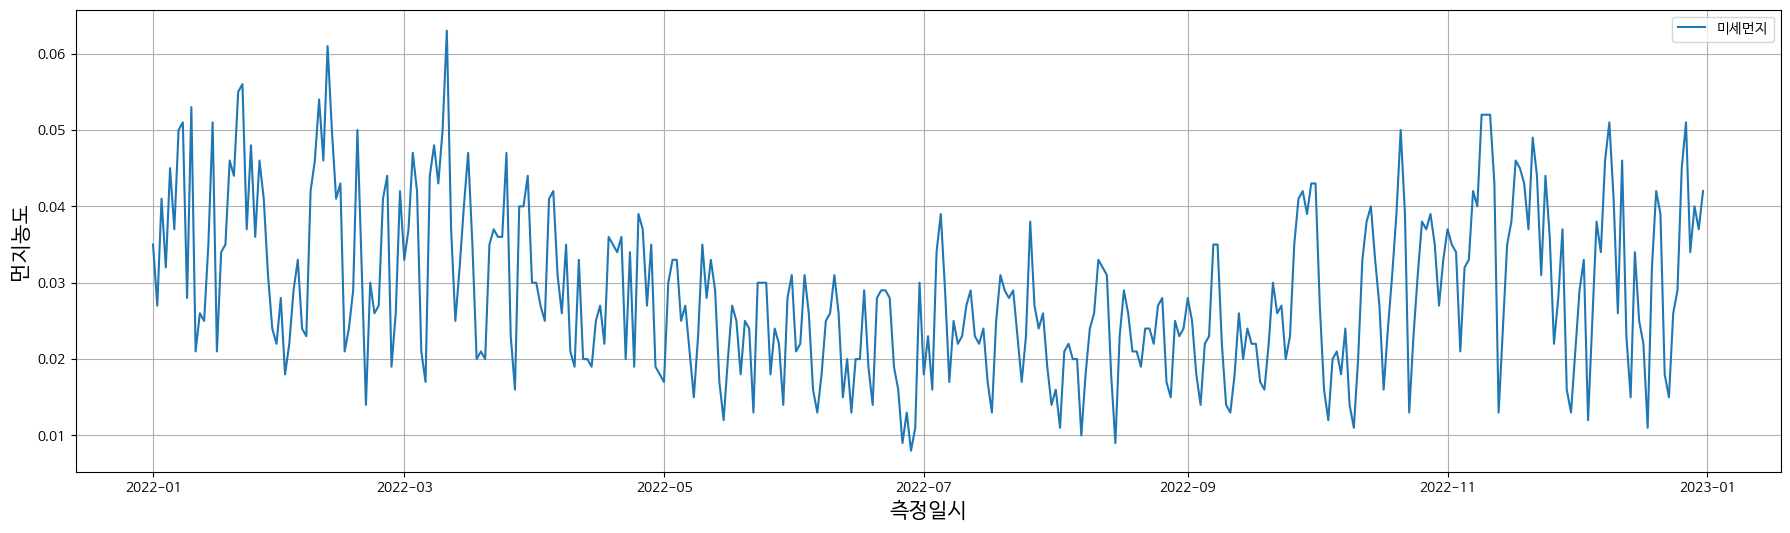

In [70]:
plt.figure(figsize = (22,6))
plt.plot(df_flt['측정일'],df_flt['미세먼지농도(㎍/㎥)'],label='미세먼지')
plt.plot(df_flt['측정일'],df_flt['초미세먼지농도(㎍/㎥)'],label='초미세먼지')
plt.xlabel('측정일시',size=15)
plt.ylabel('먼지농도',size=15)
plt.grid()
plt.legend()

이산화질소농도(ppm)
오존농도(ppm)
일산화탄소농도(ppm)
아황산가스농도(ppm)
미세먼지농도(㎍/㎥)
초미세먼지농도(㎍/㎥)

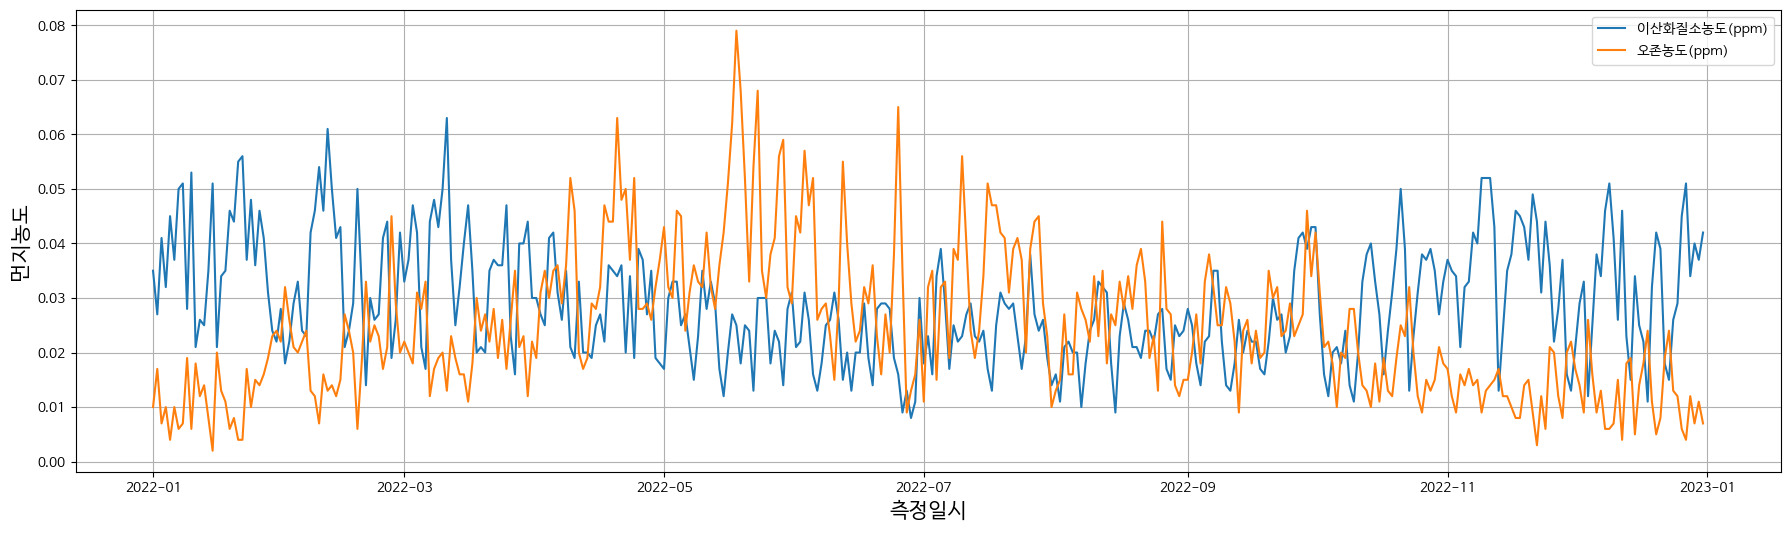

In [77]:
plt.figure(figsize = (22,6))
plt.plot(df_flt['측정일'],df_flt['이산화질소농도(ppm)'],label='이산화질소농도(ppm)')
plt.plot(df_flt['측정일'],df_flt['오존농도(ppm)'],label='오존농도(ppm)')
# plt.plot(df_flt['측정일'],df_flt['일산화탄소농도(ppm)'],label='일산화탄소농도(ppm)')
# plt.plot(df_flt['측정일'],df_flt['아황산가스농도(ppm)'],label='아황산가스농도(ppm)')
plt.xlabel('측정일시',size=15)
plt.ylabel('먼지농도',size=15)
plt.grid()
plt.legend()

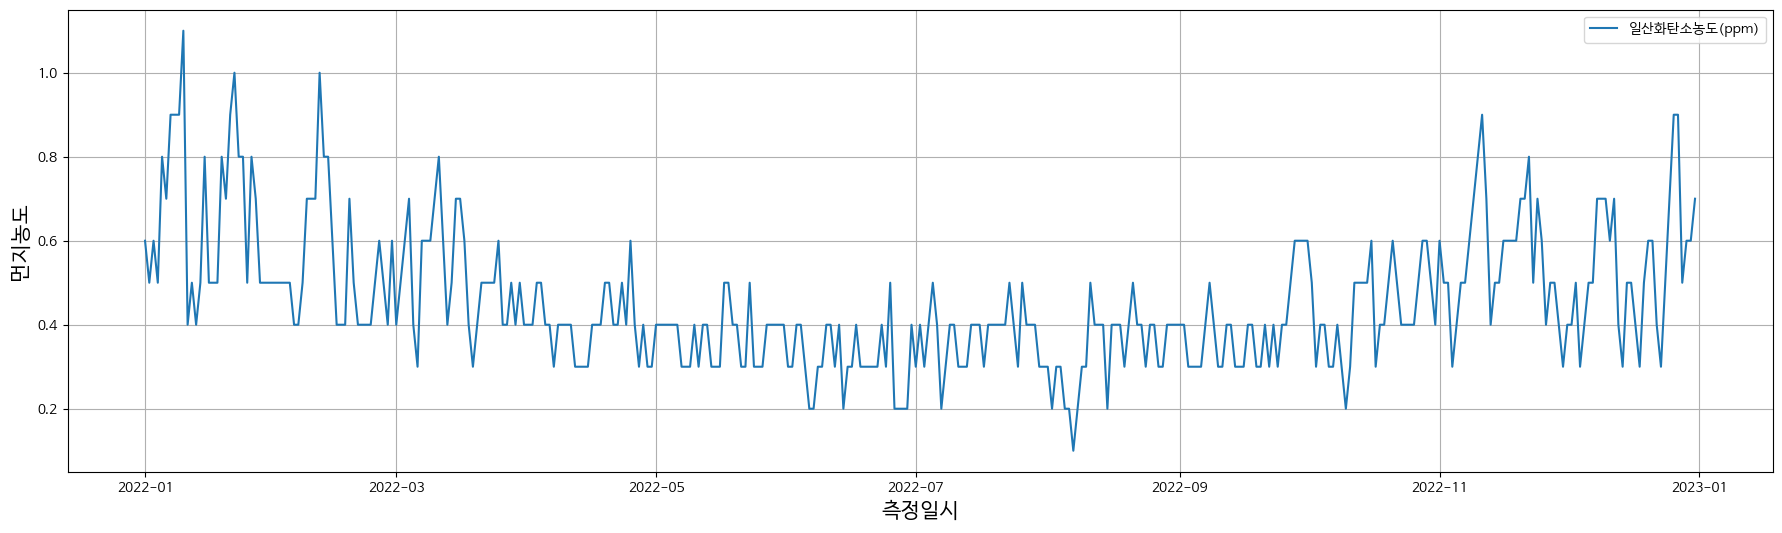

In [78]:
plt.figure(figsize = (22,6))
# plt.plot(df_flt['측정일'],df_flt['이산화질소농도(ppm)'],label='이산화질소농도(ppm)')
# plt.plot(df_flt['측정일'],df_flt['오존농도(ppm)'],label='오존농도(ppm)')
plt.plot(df_flt['측정일'],df_flt['일산화탄소농도(ppm)'],label='일산화탄소농도(ppm)')
# plt.plot(df_flt['측정일'],df_flt['아황산가스농도(ppm)'],label='아황산가스농도(ppm)')
plt.xlabel('측정일시',size=15)
plt.ylabel('먼지농도',size=15)
plt.grid()
plt.legend()

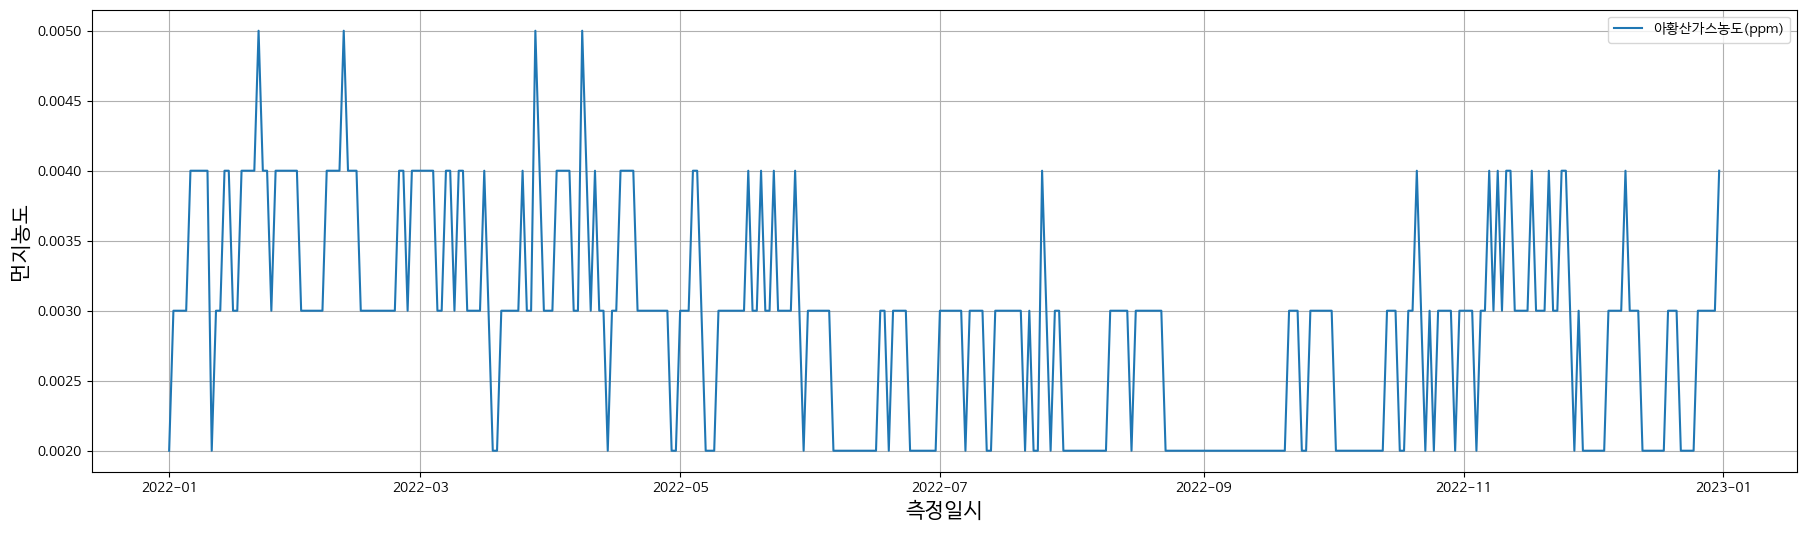

In [79]:
plt.figure(figsize = (22,6))
# plt.plot(df_flt['측정일'],df_flt['이산화질소농도(ppm)'],label='이산화질소농도(ppm)')
# plt.plot(df_flt['측정일'],df_flt['오존농도(ppm)'],label='오존농도(ppm)')
# plt.plot(df_flt['측정일'],df_flt['일산화탄소농도(ppm)'],label='일산화탄소농도(ppm)')
plt.plot(df_flt['측정일'],df_flt['아황산가스농도(ppm)'],label='아황산가스농도(ppm)')
plt.xlabel('측정일시',size=15)
plt.ylabel('먼지농도',size=15)
plt.grid()
plt.legend()

In [83]:
df_flt2 = df_flt[['측정일','미세먼지농도(㎍/㎥)']]
df_flt2

,측정일,미세먼지농도(㎍/㎥)
44,2022-01-01,31.0
93,2022-01-02,37.0
143,2022-01-03,31.0
196,2022-01-04,48.0
244,2022-01-05,56.0
...,...,...
18043,2022-12-27,51.0
18095,2022-12-28,44.0
18143,2022-12-29,35.0
18193,2022-12-30,40.0


In [84]:
ts = df_flt2.set_index('측정일')
ts.head()

,미세먼지농도(㎍/㎥)
측정일,
2022-01-01,31.0
2022-01-02,37.0
2022-01-03,31.0
2022-01-04,48.0
2022-01-05,56.0


# 2. statsmodels 라이브러리를 활용해서 분석하기
- from statsmodels.tas.seasonal import seasonal_decompose

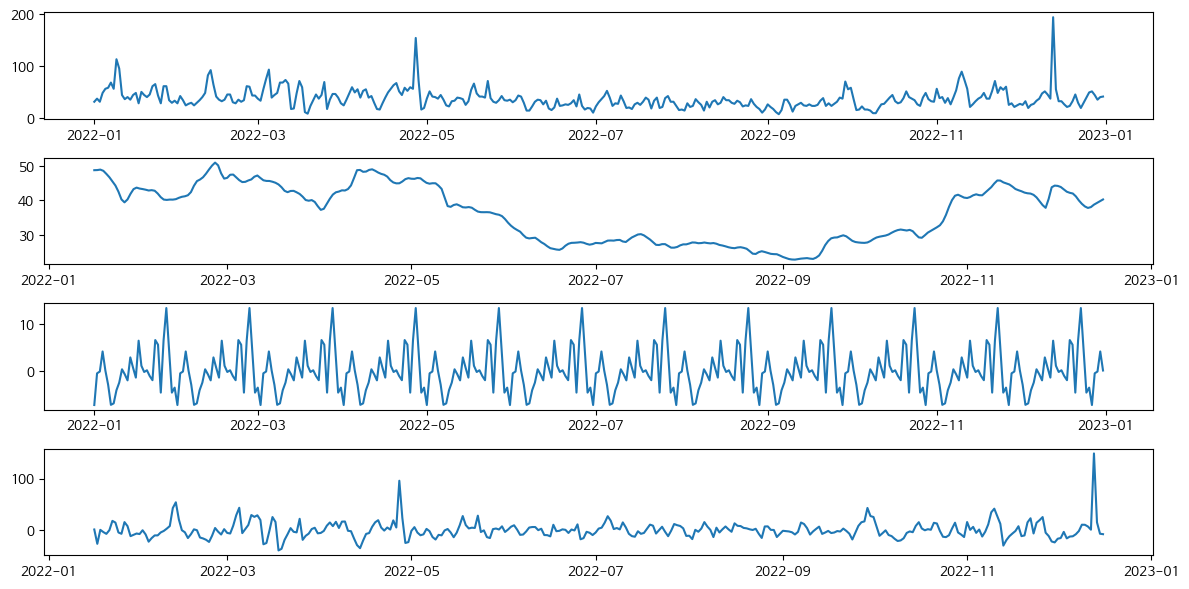

In [119]:
# 시계열 데이터의 구조를 분해해 주는 도구
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ts['미세먼지농도(㎍/㎥)'],
                           model = 'additive', # 실제 값의 추세, 계절성, 잔차를 덧셈으로 분석
                           period=30, # 1개월 단위로 계절성을 분석
                           )
# result : 분석결과
# result.observed : 실제 데이터
# result.trend    : 데이터의 장기적인 변화, 전반적으로 감소 증가
# result.seasonal : 주기적인 계절성 패턴
# result.resid    : 잔차, noise(실제 값에서 추세와 계절성을 뺀 노이즈)
fig, axes = plt.subplots(4,1, figsize = (12,6))
axes[0].plot(result.observed)
axes[1].plot(result.trend)
axes[2].plot(result.seasonal)
axes[3].plot(result.resid)
plt.tight_layout()
plt.show()

In [122]:
def plot_seasonal_decompose(result) : 
    # 시계열 데이터의 구조를 분해해 주는 도구
    fig, axes = plt.subplots(4,1, figsize = (12,6))
    result.observed.plot(ax=axes[0])
    axes[0].set_ylabel('관측값')
#     axes[0].plot(result.observed)
    axes[1].plot(result.trend)
    axes[1].set_ylabel('트랜드')
    axes[2].plot(result.seasonal)
    axes[2].set_ylabel('주기성')
    axes[3].plot(result.resid)
    axes[3].set_ylabel('잔차')
    plt.xlabel('날짜')
    plt.tight_layout()
    plt.show()

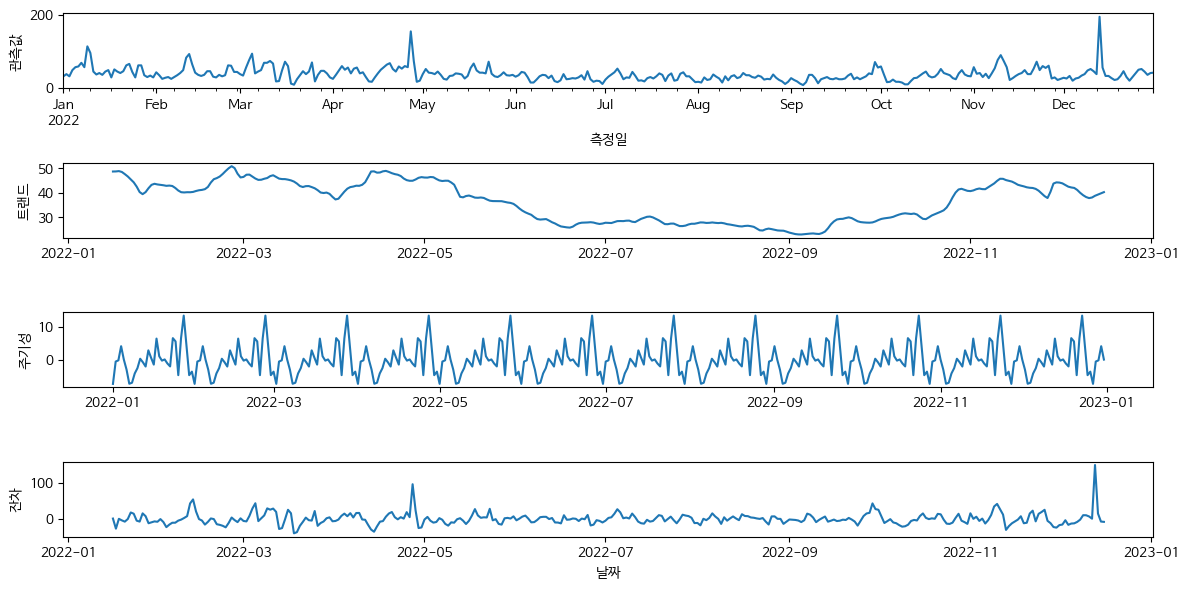

In [123]:
plot_seasonal_decompose(result)

# ※ 예측관점

# 3. Prophet을 사용해서 예측하기(RNN/LSTM/GRU의 맥락)

## Prophet 
- 계절성, 추세, 휴일효과 등을 자동으로 모델링
- pip install prophet

In [126]:
df_flt2.columns = ['ds','y'] # prophet의 fit 시 컬럼명은 반드시 ds, y로
df_flt2

,ds,y
44,2022-01-01,31.0
93,2022-01-02,37.0
143,2022-01-03,31.0
196,2022-01-04,48.0
244,2022-01-05,56.0
...,...,...
18043,2022-12-27,51.0
18095,2022-12-28,44.0
18143,2022-12-29,35.0
18193,2022-12-30,40.0


In [127]:
from prophet import Prophet
m = Prophet()
m.fit(df_flt2)

16:49:58 - cmdstanpy - INFO - Chain [1] start processing
16:49:58 - cmdstanpy - INFO - Chain [1] done processing


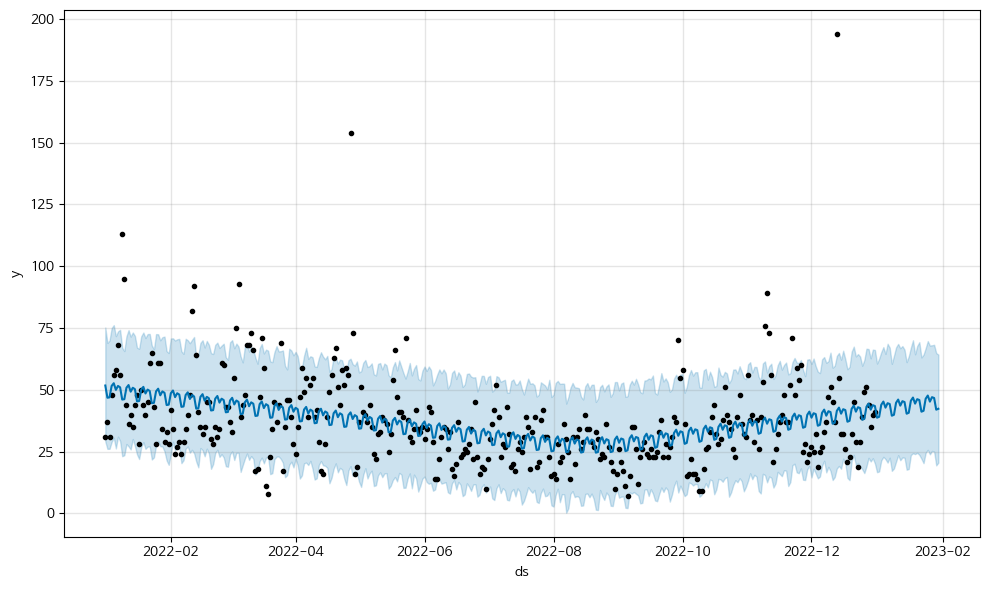

In [140]:
# 모델 m을 이용해서 30일 이후 데이터 예측
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)
m.plot(forecast)
plt.show()

In [145]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(30)

,ds,yhat,yhat_lower,yhat_upper
365,2023-01-01,38.738106,16.692320,60.662988
366,2023-01-02,39.108625,16.997710,62.620881
367,2023-01-03,43.966852,21.465401,65.265257
368,2023-01-04,45.272123,22.904310,67.312174
369,2023-01-05,42.812810,21.999361,64.547132
370,2023-01-06,44.613248,20.566007,68.664107
371,2023-01-07,44.275744,22.546578,67.078584
372,2023-01-08,39.550766,17.231366,60.554006
373,2023-01-09,39.921285,18.196708,63.787343
374,2023-01-10,44.779513,20.932482,67.189217


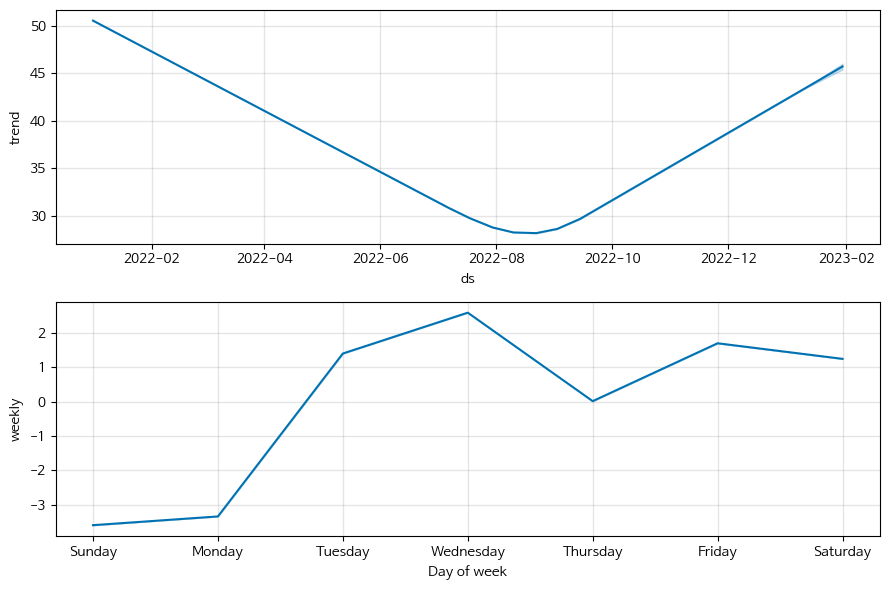

In [146]:
f2 = m.plot_components(forecast) # 트랜드와 휴일효과 그래프

In [150]:
forecast[forecast['ds']=='2023-01-16'][['yhat','yhat_lower','yhat_upper']]

,yhat,yhat_lower,yhat_upper
380,40.733946,17.996394,63.549875
